# Análise de Manutenção Preditiva Industrial

Objetivo: Prever falhas em máquinas industriais usando dados de sensores.

Tipo de problema: Classificação binária (falhou = 1 / não falhou = 0)

In [1]:
# Pandas: manipulação de tabelas (DataFrames). É a base de qualquer projeto de dados.
import pandas as pd

# NumPy: cálculos numéricos e arrays. Base matemática do Pandas.
import numpy as np

# Matplotlib: biblioteca para criar gráficos.
import matplotlib.pyplot as plt

# Seaborn: gráficos estatísticos bonitos, construído sobre o Matplotlib.
import seaborn as sns

In [2]:
# Lê o arquivo CSV e cria um DataFrame (tabela) chamado 'df'.
# 'df' é o padrão de mercado para nomear DataFrames em pandas.
df = pd.read_csv("manutencao_preditiva.csv")

## Fase 1: Análise Exploratória (EDA)

In [3]:
# .head(5) mostra as 5 primeiras linhas do DataFrame.
# Usado para inspecionar rapidamente a estrutura dos dados.
df.head(5)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [4]:
# Verifica o tamanho do dataset: (linhas, colunas)
# Base para dimensionar todo o restante da análise.
print("---- Tamanho do dataset ----")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

---- Tamanho do dataset ----
Número de linhas: 10000
Número de colunas: 14


In [5]:
# Resumo técnico das colunas: tipo de dado, quantidade de não-nulos e memória usada.
# Já detecta valores faltantes e tipos inesperados.

print("--- Resumo das Colunas e Tipos ----\n-")

df.info()

print("\n---- Valores Faltantes por Coluna ---")
df.isnull().sum()


--- Resumo das Colunas e Tipos ----
-
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
d

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

## Análise Estatística Descritiva

In [6]:
# Estatísticas descritivas das colunas numéricas.
# Revela escala, dispersão e possíveis outliers das variáveis.
print("---- Estatísticas Descritivas ----\n")
df.describe()


---- Estatísticas Descritivas ----



,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Distribuição das Variáveis Numéricas — Histogramas

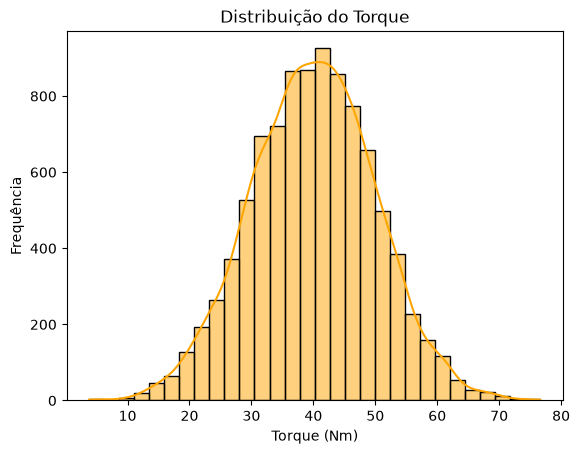

In [7]:
# Histograma para ver a distribuição do torque nas máquinas.
# Escolhemos o torque porque é uma das variáveis mais relacionadas a falhas mecânicas.

sns.histplot(data=df, x='torque_nm', bins=30, kde=True, color='orange')
plt.title('Distribuição do Torque')
plt.xlabel('Torque (Nm)')
plt.ylabel('Frequência')
plt.show()

## Desbalanceamento da Variável Alvo

/tmp/ipykernel_10876/3607906515.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='falha_maquina', palette='Set1')


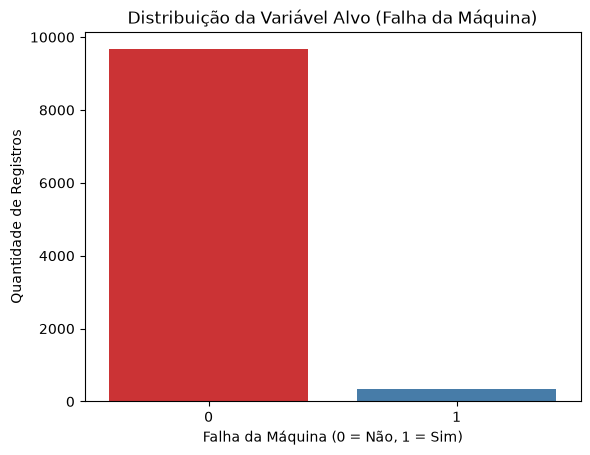

In [8]:
sns.countplot(data=df, x='falha_maquina', palette='Set1')
plt.title('Distribuição da Variável Alvo (Falha da Máquina)')
plt.xlabel('Falha da Máquina (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Registros')
plt.show()

## Correlação entre as Variáveis Numéricas — Heatmap de Pearson

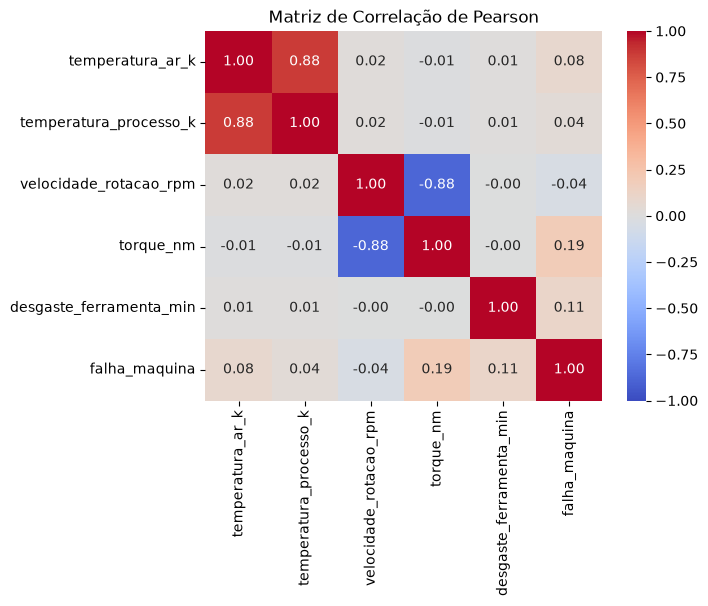

In [9]:
# Seleciona appenas as variáveis numéricas relevantes ( sensores + alvo ) para a análise de correlação.
# Exclui id_produto, udi e as colunas de tipo de falha (Não são poreditores válidos)

colunas_analise = ['temperatura_ar_k', 'temperatura_processo_k', 
                   'velocidade_rotacao_rpm', 'torque_nm',
                   'desgaste_ferramenta_min', 'falha_maquina']

# Calcular a matriz de correlação de Pearson entre essas variáveis.

matriz_correlacao = df[colunas_analise].corr(method='pearson')

# Criar um heatmap para visualizar a matriz de correlação.
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Pearson')
plt.show()

## Conclusão da Fase 1 — Diagnóstico e Direcionamento

A análise exploratória revelou três padrões importantes que direcionam
toda a estratégia de modelagem nas próximas fases.

### Distribuição das variáveis preditoras

A distribuição do torque é aproximadamente **normal**, com concentração
em torno de 40 Nm. Isso sugere que a operação padrão da fábrica está
dentro de uma faixa estável. Valores muito abaixo ou muito acima são
raros e podem estar associados a falhas o que reforça a hipótese de
que **valores extremos** são candidatos naturais a preditores da
variável alvo.

### Desbalanceamento severo da variável alvo

Este é o achado mais crítico do diagnóstico. Das 10.000 máquinas do
dataset, apenas **3,4% falharam** (339 registros), enquanto **96,6%
operaram normalmente** (9.661 registros). Este desbalanceamento tem
duas implicações diretas para a modelagem:

- Um modelo ingênuo pode simplesmente prever "não falha" para todos os
casos e ainda assim atingir 96,6% de acurácia, sem nunca detectar uma
falha real, que é justamente o que o negócio precisa identificar.
- **Acurácia sozinha não é confiável** como métrica principal neste
projeto.

**Decisão:** aplicarei a técnica **SMOTE** exclusivamente no conjunto de treinamento durante a Fase 4, preservando o conjunto de teste para evitar vazamento de dados. A avaliação final utilizará a acurácia, conforme solicitado no projeto, considerando com cautela a limitação dessa métrica diante do desbalanceamento original.

### Correlações entre variáveis

O heatmap de correlação de Pearson revelou três insights:

- **Alta correlação positiva (0,88)** entre `temperatura_ar_k` e
`temperatura_processo_k`, indicando possível **multicolinearidade** 
elas medem essencialmente o mesmo fenômeno térmico.
- **Alta correlação negativa (-0,88)** entre
`velocidade_rotacao_rpm` e `torque_nm`. Isso é fisicamente esperado:
quanto maior a rotação, menor o torque (comportamento natural de
motores elétricos).
- **Nenhuma variável isolada** apresenta correlação forte com a
variável alvo `falha_maquina`. A maior correlação é do torque (0,19),
ainda considerada fraca em termos estatísticos.

**Decisão:** como nenhuma variável sozinha é fortemente preditiva, o
modelo precisará aprender **padrões combinados** entre as variáveis, o
que exige algoritmos capazes de capturar não linearidades reforçando a escolha de comparar os modelos KNN e Árvore de Decisão solicitados no projeto.
### Diferenças de escala

A análise de `.describe()` mostrou que as variáveis operam em escalas
muito diferentes, velocidade na casa dos milhares, torque na casa das
dezenas.

**Decisão:** aplicarei **padronização (StandardScaler)** antes de
treinar o KNN, pois este algoritmo é sensível a diferenças de escala.

## Fase 2: Limpeza e Tratamento de Dados (Data Prep)

Nesta fase realizamos três tratamentos: remoção de duplicatas,
imputação de valores ausentes e análise de outliers via boxplot.

In [10]:
# Verificar linhas totalmente idênticas no dataset, que podem ser removidas para evitar viés na análise.
print(f"Linhas duplicadas no dataset: {df.duplicated().sum()}")

# Remove duplicadas caso existam (drop_duplicates matém a primeira ocorrência e remove as demais).
df = df.drop_duplicates()

print(f"Dimensão após a remoção das duplicadas: {df.shape}")

Linhas duplicadas no dataset: 0
Dimensão após a remoção das duplicadas: (10000, 14)


In [11]:
# Colunas que apresentaram valores ausentes na Fase 1.
colunas_com_nulos = ['temperatura_ar_k', 'temperatura_processo_k',
                     'velocidade_rotacao_rpm', 'torque_nm']

# Monta uma tabela de diagnóstico para embasar a escolha média vs mediana.
diagnostico = pd.DataFrame({
    'nulos': df[colunas_com_nulos].isnull().sum(),
    'media': df[colunas_com_nulos].mean().round(2),
    'mediana': df[colunas_com_nulos].median().round(2),
    'assimetria': df[colunas_com_nulos].skew().round(3)
})

diagnostico

,nulos,media,mediana,assimetria
temperatura_ar_k,500,300.00,300.1,0.115
temperatura_processo_k,500,310.00,310.1,0.016
velocidade_rotacao_rpm,500,1539.25,1504.0,1.995
torque_nm,500,39.97,40.1,-0.008


## Justificativa da estratégia de imputação

As quatro colunas analisadas apresentam **500 valores ausentes** cada.

Para definir a melhor estratégia de preenchimento dos valores ausentes, foram comparadas a **média**, a **mediana** e a **assimetria** de cada variável.

- Nas colunas **temperatura_ar_k**, **temperatura_processo_k** e **torque_nm**, a média e a mediana apresentaram valores muito próximos. Isso indica que os dados possuem uma distribuição relativamente equilibrada. Por esse motivo, foi utilizada a **média** para realizar a imputação dos valores ausentes.

- Já a coluna **velocidade_rotacao_rpm** apresentou maior diferença entre a média e a mediana, além de maior assimetria. Isso indica que existem valores mais elevados influenciando a média. Dessa forma, foi escolhida a **mediana**, por ser menos sensível a valores extremos.

Assim, a estratégia de imputação foi definida de acordo com o comportamento de cada variável, buscando preservar as características originais do conjunto de dados.

In [12]:
# Colunas simétricas: imputação pela MÉDIA.
colunas_media = ['temperatura_ar_k', 'temperatura_processo_k', 'torque_nm']

for coluna in colunas_media:
    df[coluna] = df[coluna].fillna(df[coluna].mean())

# Coluna assimétrica: imputação pela MEDIANA.
df['velocidade_rotacao_rpm'] = df['velocidade_rotacao_rpm'].fillna(
    df['velocidade_rotacao_rpm'].median()
)

# Confirma que não restaram valores ausentes.
print("Valores nulos restantes por coluna:")
print(df.isnull().sum())

Valores nulos restantes por coluna:
udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64


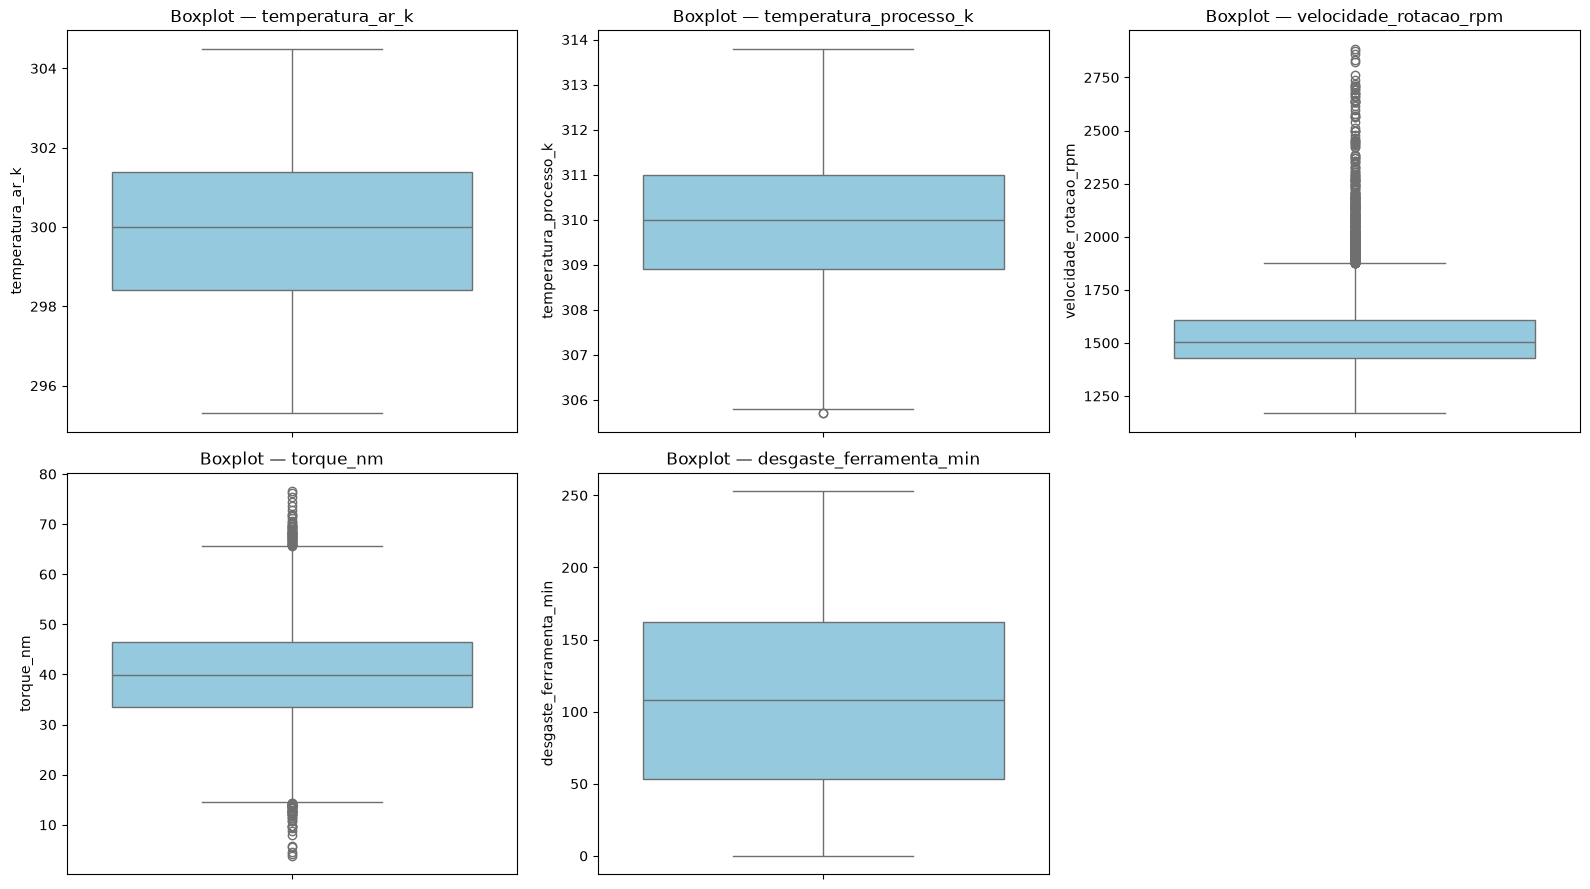

In [13]:
# Lista das variáveis numéricas que serão analisadas nos boxplots.
# O objetivo é identificar possíveis valores extremos em cada coluna.

variaveis_explicativas = ['temperatura_ar_k', 'temperatura_processo_k',
                          'velocidade_rotacao_rpm', 'torque_nm',
                          'desgaste_ferramenta_min']

# Cria uma grade com 2 linhas e 3 colunas para organizar os 5 boxplots.

fig, eixos = plt.subplots(2, 3, figsize=(16, 9))

# Transforma a grade 2x3 em uma lista simples de 6 posições.
# Isso facilita o acesso a cada espaço do gráfico dentro do laço for.

eixos = eixos.flatten()  

# Percorre a lista de variáveis e cria um boxplot para cada coluna.

for i, coluna in enumerate(variaveis_explicativas):

# Cria o boxplot da coluna atual dentro da posição correspondente da grade.

    sns.boxplot(data=df, y=coluna, ax=eixos[i], color='skyblue')

  # Define o título de cada gráfico usando o nome da coluna.   
    eixos[i].set_title(f'Boxplot — {coluna}')

# Remove o sexto espaço da grade, pois existem apenas 5 variáveis.
fig.delaxes(eixos[5])

# Ajusta automaticamente o espaçamento entre os gráficos.
plt.tight_layout()

# Exibe todos os boxplots.
plt.show()

## Análise dos outliers

Os boxplots indicaram a presença de valores extremos, principalmente nas variáveis **velocidade_rotacao_rpm** e **torque_nm**.

Após a análise, foi decidido **não remover esses valores**, pois eles podem representar condições reais de operação das máquinas e contribuir para que o modelo consiga identificar situações de falha.

Como o objetivo do projeto é prever falhas mecânicas, a remoção desses valores poderia eliminar informações importantes para o treinamento do modelo.

Portanto, os outliers foram mantidos no conjunto de dados para preservar informações que podem ser relevantes para a etapa de modelagem preditiva.

## Fase 3: Feature Engineering

Nesta fase vamos criar uma nova coluna combinando duas variáveis que já existem no dataset.

In [14]:
# Cria uma nova coluna chamada 'potencia', multiplicando a velocidade de
# rotação pelo torque. Essa multiplicação representa o esforço total
# que o motor está fazendo, juntando "quão rápido" e "quão forte" em um só número.

df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']

# Confere se a coluna nova ficou com algum valor vazio (NaN).
# Se aparecer 0 aqui, quer dizer que o cálculo funcionou em todas as linhas.
print("Valores nulos na coluna potencia:", df['potencia'].isnull().sum())

# Mostra as primeiras linhas para ver como ficou a nova coluna.
df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head()

Valores nulos na coluna potencia: 0


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.800000,66382.800000
1,1408.0,46.300000,65190.400000
2,1498.0,49.400000,74001.200000
3,1504.0,39.974168,60121.149305
4,1408.0,40.000000,56320.000000


### Por que criamos a coluna potência

As colunas de rotação e torque, analisadas separadamente, não mostraram
correlação forte com a falha da máquina (a maior encontrada foi 0,19, no
torque). Isso sugere que nenhuma das duas, sozinha, explica bem quando a
máquina vai falhar.

Rotação e torque representam aspectos diferentes do funcionamento do motor:
uma mostra a velocidade, a outra mostra a força aplicada. Multiplicando as
duas, criamos a coluna `potencia`, que representa o esforço total que o
motor está fazendo.

A ideia é que esse esforço combinado tenha uma relação mais forte com a
falha do que cada variável isolada, já que uma máquina sob esforço alto
está mais próxima do limite de operação.

Conferimos que a nova coluna não gerou nenhum valor nulo, já que as colunas
de origem foram tratadas na Fase 2.

# Fase 4: Divisão e Balanceamento dos Dados

Nesta etapa, será realizada a preparação dos dados para o treinamento dos modelos de Machine Learning.

Primeiramente, a variável categórica `tipo` será convertida para valores numéricos utilizando One-Hot Encoding. Em seguida, serão definidas as variáveis preditoras (X) e a variável alvo (y). Por fim, os dados serão divididos em treino e teste e será aplicado o balanceamento apenas no conjunto de treinamento, evitando vazamento de dados (Data Leakage).

In [15]:
# Converte a variável categórica 'tipo' em colunas numéricas.
tipo_numerico = pd.get_dummies(df['tipo'], prefix='tipo')

In [16]:
# Remove a coluna categórica original e adiciona as novas colunas numéricas.
df = pd.concat([df.drop(columns='tipo'), tipo_numerico], axis=1)

In [17]:
# Seleciona as variáveis preditoras.
colunas_X = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min',
    'potencia',
    'tipo_H',
    'tipo_L',
    'tipo_M'
]

# Separa as variáveis preditoras (X) da variável alvo (y).
X = df[colunas_X]
y = df['falha_maquina']

# Confere se a separação foi realizada corretamente.
print("---- Separação concluída ----")
print("Colunas do X:", X.columns.tolist())
print("Variável alvo:", y.name)

---- Separação concluída ----
Colunas do X: ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia', 'tipo_H', 'tipo_L', 'tipo_M']
Variável alvo: falha_maquina


## Divisão dos dados em treino e teste

Após definir as variáveis preditoras (X) e a variável alvo (y), os dados serão divididos em dois conjuntos:

- **Treino (80%)**, utilizado para treinar o modelo;
- **Teste (20%)**, utilizado para avaliar o desempenho do modelo em dados que ele nunca viu.

Será utilizado o parâmetro `stratify=y` para manter a mesma proporção da variável alvo nos dois conjuntos.

In [18]:
# Importa a função responsavel por dividir os dados em treino e teste.
from sklearn.model_selection import train_test_split

# Divide as variáveis preditoras e a variável alvo em conjuntos de treino e teste.
# test_size=0.2 reserva 20% dos dados para teste e mantém 80% para treino.
# random_state=42 garante que a divisão seja sempre a mesma ao executar o código.
# stratify=y mantém a proporção de falhas e não falhas nos dois conjuntos.

x_treino, x_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) 

# Exibe as dimensões dos conjuntos para confirmar se a divisão foi realizada corretamente.

print("---- Dimensões dos Conjuntos ----")
print("Dimensões de X_treino:", x_treino.shape[0])
print("Dimensões de X_teste:", x_teste.shape[0])
print("Dimensões de Y_treino:", y_treino.shape[0])
print("Dimensões de Y_teste:", y_teste.shape[0])

# Confere se a proporção de falhas ficou parecida nos dois lados
print("\nProporção de falhas no treino:", y_treino.mean())
print("Proporção de falhas no teste:", y_teste.mean())

---- Dimensões dos Conjuntos ----
Dimensões de X_treino: 8000
Dimensões de X_teste: 2000
Dimensões de Y_treino: 8000
Dimensões de Y_teste: 2000

Proporção de falhas no treino: 0.033875
Proporção de falhas no teste: 0.034


## Balanceamento dos dados de treinamento

Após a divisão entre treino e teste, será aplicada uma técnica de balanceamento apenas no conjunto de treinamento.

Essa estratégia evita o **Data Leakage (vazamento de dados)**, garantindo que o conjunto de teste permaneça inalterado e represente corretamente dados que o modelo nunca viu durante o treinamento.

In [19]:
# Importa a técnica SMOTE da biblioteca imbalanced-learn.
from imblearn.over_sampling import SMOTE

# Cria o objeto SMOTE.
# random_state=42 garante que o resultado seja reproduzível.
smote = SMOTE(random_state=42)

# Aplica o balanceamento somente nos dados de treinamento.
# x_treino_balanceado recebe as variáveis preditoras balanceadas.
# y_treino_balanceado recebe a variável alvo balanceada.
x_treino_bal, y_treino_bal = smote.fit_resample(x_treino, y_treino)

# Exibe a quantidade de exemplos de cada classe antes do balanceamento.
print("Antes do SMOTE:")
print(y_treino.value_counts())

# Exibe a quantidade de exemplos de cada classe após o balanceamento.
print("\nDepois do SMOTE:")
print(y_treino_bal.value_counts())

Antes do SMOTE:
falha_maquina
0    7729
1     271
Name: count, dtype: int64

Depois do SMOTE:
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


## Resultado do balanceamento

Antes da aplicação do SMOTE, o conjunto de treinamento apresentava forte desbalanceamento:

- **7729 registros sem falha**;
- **271 registros com falha**.

Após a aplicação do SMOTE, as duas classes passaram a ter **7729 registros cada**.

O balanceamento foi aplicado somente ao conjunto de treinamento. O conjunto de teste permaneceu inalterado, evitando vazamento de dados e preservando uma avaliação mais próxima do cenário real.

# Fase 5 - Escalonamento de Variáveis (StandardScaler)

Nesta etapa será realizado o escalonamento das variáveis contínuas utilizando o StandardScaler.

O objetivo dessa etapa é padronizar a escala das variáveis utilizadas pelo algoritmo K-Nearest Neighbors (KNN), evitando que atributos com valores numéricos maiores tenham maior influência no cálculo das distâncias entre as observações.

Para isso, será utilizado o método `fit_transform()` no conjunto de treinamento e o método `transform()` no conjunto de teste. Essa abordagem garante que os parâmetros de escalonamento sejam aprendidos apenas com os dados de treinamento, evitando o vazamento de dados (Data Leakage).

Já os dados destinados ao modelo de Árvore de Decisão permanecerão sem escalonamento, pois esse algoritmo realiza divisões baseadas em regras de decisão e não depende da escala das variáveis para construir o modelo.

In [20]:
# Importa a classe StandardScaler da biblioteca scikit-learn.
# Essa classe será utilizada para padronizar somente as variáveis contínuas
# destinadas ao modelo KNN.
from sklearn.preprocessing import StandardScaler

# Define quais colunas são variáveis contínuas.
# As colunas tipo_H, tipo_L e tipo_M não entram nesta lista porque
# representam categorias criadas pelo One-Hot Encoding.
colunas_continuas = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min',
    'potencia'
]

# Cria cópias dos dados para preservar os conjuntos originais.
# Nessas cópias, somente as variáveis contínuas serão escalonadas.
x_treino_bal_escalonado = x_treino_bal.copy()
x_teste_escalonado = x_teste.copy()

# Cria o objeto responsável pelo escalonamento.
scaler = StandardScaler()

# Aprende a média e o desvio padrão somente das variáveis contínuas
# do conjunto de treinamento e realiza o escalonamento.
x_treino_bal_escalonado[colunas_continuas] = scaler.fit_transform(
    x_treino_bal[colunas_continuas]
)

# Utiliza a mesma média e o mesmo desvio padrão aprendidos no treinamento
# para escalonar as variáveis contínuas do conjunto de teste.
x_teste_escalonado[colunas_continuas] = scaler.transform(
    x_teste[colunas_continuas]
)

# Confere a média somente das variáveis contínuas escalonadas.
# Os valores devem ficar aproximadamente iguais a 0.
print("Média das variáveis contínuas no treino escalonado:")
print(
    x_treino_bal_escalonado[colunas_continuas]
    .mean()
    .round(2)
)

# Confere o desvio padrão somente das variáveis contínuas escalonadas.
# Os valores devem ficar aproximadamente iguais a 1.
print("\nDesvio-padrão das variáveis contínuas no treino escalonado:")
print(
    x_treino_bal_escalonado[colunas_continuas]
    .std(ddof=0)
    .round(2)
)

Média das variáveis contínuas no treino escalonado:
temperatura_ar_k          -0.0
temperatura_processo_k     0.0
velocidade_rotacao_rpm     0.0
torque_nm                  0.0
desgaste_ferramenta_min    0.0
potencia                   0.0
dtype: float64

Desvio-padrão das variáveis contínuas no treino escalonado:
temperatura_ar_k           1.0
temperatura_processo_k     1.0
velocidade_rotacao_rpm     1.0
torque_nm                  1.0
desgaste_ferramenta_min    1.0
potencia                   1.0
dtype: float64


### Por que a Árvore de Decisão não recebe escalonamento

O `StandardScaler` será aplicado apenas aos dados destinados ao modelo KNN, pois esse algoritmo utiliza o cálculo de distâncias para identificar as observações mais próximas.

Quando as variáveis possuem escalas muito diferentes, uma coluna com valores numericamente maiores, como `potencia`, pode exercer influência desproporcional no cálculo da distância. O escalonamento padroniza as variáveis contínuas para que tenham média próxima de 0 e desvio-padrão próximo de 1, evitando que uma variável domine o cálculo apenas por causa de sua escala.

A Árvore de Decisão não utiliza cálculos de distância. Ela constrói regras de separação dentro de cada variável, como `torque_nm > 50`. Por esse motivo, alterar a escala das variáveis não modifica a lógica utilizada pelo algoritmo para encontrar os pontos de corte.

As colunas `tipo_H`, `tipo_L` e `tipo_M`, criadas pelo One-Hot Encoding, também serão mantidas sem escalonamento, pois representam categorias e não variáveis contínuas.

Assim, os dados escalonados serão utilizados no KNN, enquanto a Árvore de Decisão utilizará os dados originais, sem escalonamento.

# Fase 6 - Ajuste de Parâmetros e Combate ao Overfitting

Nesta etapa serão treinados dois modelos de classificação: K-Nearest Neighbors (KNN) e Árvore de Decisão.

O objetivo é avaliar como diferentes configurações dos principais parâmetros de cada algoritmo influenciam o desempenho do modelo nos conjuntos de treinamento e de teste.

No KNN será variado o parâmetro `n_neighbors`, enquanto na Árvore de Decisão será variado o parâmetro `max_depth`.

Ao final, as acurácias obtidas em cada configuração serão comparadas para identificar possíveis casos de overfitting e selecionar a configuração que apresentar melhor capacidade de generalização.

In [21]:
# Importa o algoritmo K-Nearest Neighbors para problemas de classificação.
from sklearn.neighbors import KNeighborsClassifier

# Define os valores de K que serão testados.
# Foram escolhidos valores ímpares para reduzir a possibilidade de empate entre as classes durante a votação dos vizinhos.
valores_k = [3, 5, 7]

# Cria uma lista vazia para armazenar os resultados de cada modelo.
resultados_knn = []

# Percorre cada valor presente na lista valores_k.
for k in valores_k:

    # Cria um modelo KNN utilizando o valor atual de K.
    modelo_knn = KNeighborsClassifier(n_neighbors=k)

    # Treina o modelo utilizando os dados de treinamento
    # balanceados e escalonados.
    modelo_knn.fit(
        x_treino_bal_escalonado,
        y_treino_bal
    )

    # Calcula a acurácia do modelo nos próprios dados de treinamento.
    acuracia_treino = modelo_knn.score(
        x_treino_bal_escalonado,
        y_treino_bal
    )

    # Calcula a acurácia do modelo nos dados de teste.
    acuracia_teste = modelo_knn.score(
        x_teste_escalonado,
        y_teste
    )

    # Armazena o valor de K e as acurácias em um dicionário.
    resultados_knn.append({
        'K': k,
        'Acurácia no treino': acuracia_treino,
        'Acurácia no teste': acuracia_teste
    })

# Converte a lista de resultados em uma tabela.
resultados_knn_df = pd.DataFrame(resultados_knn)

# Exibe a tabela com os valores arredondados para quatro casas decimais.
resultados_knn_df.round(4)

,K,Acurácia no treino,Acurácia no teste
0,3,0.9774,0.9265
1,5,0.9691,0.9225
2,7,0.9642,0.9160


### Ajuste do parâmetro `max_depth` na Árvore de Decisão

Nesta etapa, serão treinados modelos de Árvore de Decisão utilizando diferentes valores para o parâmetro `max_depth`.

Esse parâmetro controla a profundidade máxima da árvore, ou seja, limita a quantidade de níveis e decisões que o modelo pode criar.

Serão testadas as seguintes configurações:

- `max_depth = 3`: limita a árvore a três níveis;
- `max_depth = 5`: permite uma árvore mais detalhada;
- `max_depth = None`: não estabelece um limite de profundidade.

Para cada configuração, serão registradas as acurácias obtidas nos dados de treinamento e de teste. Essa comparação permitirá identificar possíveis sinais de underfitting ou overfitting e selecionar a configuração que apresenta melhor equilíbrio entre aprendizado e generalização.

A Árvore de Decisão será treinada com os dados balanceados, mas sem escalonamento, pois esse algoritmo não utiliza cálculos de distância entre os registros.

In [22]:
# Importa o algoritmo de Árvore de Decisão da biblioteca scikit-learn.
# Esse algoritmo será utilizado para aprender regras de decisão
# capazes de classificar se ocorreu ou não uma falha na máquina.
from sklearn.tree import DecisionTreeClassifier

# Define os valores de profundidade máxima que serão testados.
# O valor None permite que a árvore cresça sem um limite predefinido.
valores_profundidade = [3, 5, None]

# Cria uma lista vazia para armazenar os resultados
# de acurácia obtidos em cada configuração.
resultados_arvore = []

# Percorre cada valor presente na lista valores_profundidade.
for profundidade in valores_profundidade:

    # Cria um novo modelo de Árvore de Decisão.
    # max_depth controla a profundidade máxima da árvore.
    # random_state=42 garante que o resultado possa ser reproduzido.
    modelo_arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )

    # Treina o modelo utilizando os dados de treinamento balanceados.
    # A Árvore de Decisão não precisa dos dados escalonados.
    modelo_arvore.fit(x_treino_bal, y_treino_bal)

    # Calcula a acurácia do modelo nos dados utilizados no treinamento.
    acuracia_treino = modelo_arvore.score(
        x_treino_bal,
        y_treino_bal
    )

    # Calcula a acurácia do modelo nos dados de teste.
    # Esses dados não foram utilizados durante o treinamento.
    acuracia_teste = modelo_arvore.score(
        x_teste,
        y_teste
    )

    # Armazena a profundidade testada e as respectivas acurácias.
    resultados_arvore.append({
        "max_depth": profundidade,
        "Acurácia de treino": acuracia_treino,
        "Acurácia de teste": acuracia_teste
    })

# Converte a lista de resultados em um DataFrame.
# Isso facilita a visualização e a comparação entre as configurações.
resultados_arvore_df = pd.DataFrame(resultados_arvore)

# Exibe os resultados com quatro casas decimais.
resultados_arvore_df.round(4)

,max_depth,Acurácia de treino,Acurácia de teste
0,3.0,0.8581,0.8595
1,5.0,0.9035,0.9120
2,NaN,0.9967,0.9500


### Análise do overfitting

**KNN**

Com `K = 3`, o modelo apresentou acurácia de 97,74% no treinamento e 92,65% no teste, uma diferença de 5,09 pontos percentuais.

Com `K = 5`, foram obtidas acurácias de 96,91% no treinamento e 92,25% no teste, uma diferença de 4,66 pontos percentuais.

Com `K = 7`, o modelo apresentou acurácia de 96,42% no treinamento e 91,60% no teste, uma diferença de 4,82 pontos percentuais.

As três configurações apresentaram acurácia superior no treinamento, indicando sinais de overfitting de magnitude semelhante. Embora `K = 5` tenha apresentado a menor diferença entre treinamento e teste, ela foi apenas 0,43 ponto percentual menor que a diferença observada com `K = 3`.

Como `K = 3` alcançou a maior acurácia no teste, de 92,65%, e apresentou um nível de overfitting semelhante aos demais valores, ele foi selecionado como a melhor configuração do KNN.

**Árvore de Decisão**

Com `max_depth = 3`, a árvore apresentou acurácia de 85,81% no treinamento e 85,95% no teste. Os resultados ficaram próximos, mas essa configuração apresentou o menor desempenho, indicando que a árvore pode estar simples demais para aprender todos os padrões dos dados.

Com `max_depth = 5`, foram obtidas acurácias de 90,35% no treinamento e 91,20% no teste. Os valores ficaram próximos, demonstrando estabilidade entre treinamento e teste.

Quando treinada sem limite de profundidade (`max_depth = None`), a árvore atingiu 99,67% de acurácia no treinamento e 95,00% no teste. A diferença de 4,67 pontos percentuais indica overfitting, pois o modelo aprendeu excessivamente os dados de treinamento.

**Conclusão da Fase 6**

As configurações selecionadas foram:

- KNN com `K = 3`;
- Árvore de Decisão com `max_depth = 5`.

O `K = 3` foi escolhido por apresentar a maior acurácia de teste entre as configurações do KNN, mantendo um nível de overfitting semelhante aos demais valores.

Na Árvore de Decisão, `max_depth = 5` foi escolhida por apresentar estabilidade entre treinamento e teste, evitando o sobreajuste observado na árvore sem limite de profundidade.

Essas configurações serão utilizadas na Fase 7 para calcular as acurácias finais e realizar a comparação entre os modelos.

# Fase 7 - Avaliação da Acurácia e Veredito Final

Nesta etapa, serão avaliadas as configurações selecionadas durante o ajuste de hiperparâmetros realizado na Fase 6.

Para o KNN, será utilizado `n_neighbors = 3`, configuração que apresentou a maior acurácia no teste e um nível de overfitting semelhante aos demais valores avaliados.

Para a Árvore de Decisão, será utilizado `max_depth = 5`, configuração que apresentou o melhor desempenho entre as árvores que não demonstraram sinais de overfitting.

Os dois modelos serão treinados novamente utilizando seus respectivos conjuntos de dados. Em seguida, suas acurácias finais serão calculadas exclusivamente nos dados de teste.

O KNN utilizará os dados escalonados, pois seu funcionamento depende do cálculo de distâncias. A Árvore de Decisão utilizará os dados sem escalonamento, pois realiza divisões baseadas em limites e regras de decisão.

In [23]:
# Cria o modelo final do KNN com K = 3.
# Essa configuração apresentou a maior acurácia no teste
# e um nível de overfitting semelhante aos outros valores avaliados.
modelo_final_knn = KNeighborsClassifier(n_neighbors=3)

# Treina o KNN utilizando os dados de treinamento
# balanceados e com as variáveis contínuas escalonadas.
modelo_final_knn.fit(
    x_treino_bal_escalonado,
    y_treino_bal
)

# Calcula a acurácia final do KNN nos dados de teste escalonados.
acuracia_final_knn = modelo_final_knn.score(
    x_teste_escalonado,
    y_teste
)

# Cria o modelo final da Árvore de Decisão com profundidade máxima 5.
# Essa foi a configuração estável selecionada na Fase 6.
# random_state=42 garante que o resultado possa ser reproduzido.
modelo_final_arvore = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Treina a Árvore de Decisão utilizando os dados de treinamento
# balanceados e sem escalonamento.
modelo_final_arvore.fit(
    x_treino_bal,
    y_treino_bal
)

# Calcula a acurácia final da Árvore nos dados de teste
# sem escalonamento.
acuracia_final_arvore = modelo_final_arvore.score(
    x_teste,
    y_teste
)

# Exibe as acurácias finais em formato percentual,
# com duas casas decimais.
print(f"Acurácia final do KNN (K = 3): {acuracia_final_knn:.2%}")
print(
    f"Acurácia final da Árvore de Decisão "
    f"(max_depth = 5): {acuracia_final_arvore:.2%}"
)

Acurácia final do KNN (K = 3): 92.65%
Acurácia final da Árvore de Decisão (max_depth = 5): 91.20%


## Comparação dos modelos e veredito final

O modelo KNN, utilizando `n_neighbors = 3`, apresentou acurácia final de **92,65%** nos dados de teste.

A Árvore de Decisão, utilizando `max_depth = 5`, apresentou acurácia final de **91,20%** nos mesmos dados de teste.

A diferença entre os modelos foi de **1,45 ponto percentual** a favor do KNN. Portanto, considerando a métrica de acurácia solicitada no projeto, o KNN apresentou o desempenho superior no conjunto de teste.

Dessa forma, o modelo recomendado para ser adotado pela empresa é o **KNN com `K = 3`**, utilizando o escalonamento das variáveis contínuas com o `StandardScaler`.

Essa conclusão considera os resultados obtidos no conjunto de teste e o escopo definido para o projeto. Em uma aplicação industrial real, outras métricas relacionadas à identificação de falhas também poderiam ser avaliadas para complementar a decisão.